# Confusion Matrix

# A confusion matrix is a simple table used to score a machine learning model's
# performance on a yes/no guessing task. It shows exactly where the model got
# things right and where it got "confused/wrong". The confusion matrix helps us
# understand not just how many predictions were correct, but also what kinds of
# mistakes the model made.

In our Titanic prediction model, the goal is to predict whether a passenger
## Survived (Positive/Yes) or Died (Negative/No)
A confusion matrix splits the model's guesses into four distinct quadrants:
### True/Actual Positive (TP)
### True/Actual Negative (TN)
### False Positive (FP)
### False Negative (FN)
For this project: Positive = survived, Negative = did not survive


## 97 (True Negatives - TN): The model predicted these passengers Died, and they
actually died. The model was correct.
## 46 (True Positives - TP): The model predicted these passengers Survived, and
they actually survived. The model was correct.
## 12 (False Positives - FP): The model predicted these passengers Survived, but
they actually died. This is a false alarm.
## 23 (False Negatives - FN): The model predicted these passengers Died, but they
actually survived. The model completely missed them

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
#import file
titanic_data = pd.read_csv('data/titanic.csv')
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,PaCh,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [6]:
# We've done viz for this dataset, so I'll skip it.
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Name      887 non-null    object 
 3   Sex       887 non-null    object 
 4   Age       887 non-null    float64
 5   SibSp     887 non-null    int64  
 6   PaCh      887 non-null    int64  
 7   Fare      887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [7]:
titanic_data["Survived"].value_counts()

Survived
0    545
1    342
Name: count, dtype: int64

In [8]:
titanic_data.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
PaCh        0
Fare        0
dtype: int64

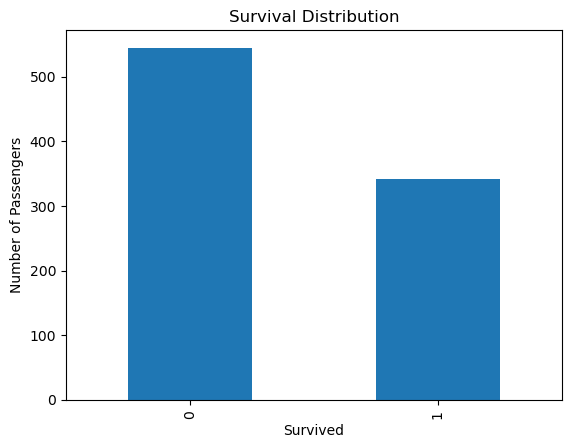

In [9]:
titanic_data["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.show()

In [10]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'PaCh', 'Fare']
target = 'Survived'

In [11]:
X = titanic_data[features].copy()
y = titanic_data[target].copy()

In [12]:
X.head()

,Pclass,Sex,Age,SibSp,PaCh,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


In [13]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [14]:
X['Sex'] = X['Sex'].apply(lambda x: 1 if x == 'female' else 0)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (709, 6)
Testing data: (178, 6)


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Train Random Forest
forest_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3
)
forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
forest_predictions = forest_model.predict(X_test)
forest_accuracy = accuracy_score(
    y_test,
    forest_predictions
)
print("Random Forest Accuracy:", forest_accuracy)

Random Forest Accuracy: 0.7528089887640449


In [20]:
print(classification_report(y_test, forest_predictions))

              precision    recall  f1-score   support

           0       0.75      0.90      0.82       111
           1       0.76      0.51      0.61        67

    accuracy                           0.75       178
   macro avg       0.75      0.70      0.71       178
weighted avg       0.75      0.75      0.74       178



In [21]:
# Tune the Random Forest
forest_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, 10]
}
forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    forest_params,
    cv=5,
    scoring="accuracy"
)
forest_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [22]:
print("Best Parameters:")
print(forest_grid.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(forest_grid.best_score_)

Best Parameters:
{'max_depth': 5, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.8363999600439517


In [23]:
best_forest = forest_grid.best_estimator_
tuned_forest_predictions = best_forest.predict(X_test)
tuned_forest_accuracy = accuracy_score(
    y_test,
    tuned_forest_predictions
)
print(
    "Tuned Random Forest Accuracy:",
    tuned_forest_accuracy

)

Tuned Random Forest Accuracy: 0.7921348314606742


In [25]:
print(classification_report(y_test, tuned_forest_predictions))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       111
           1       0.80      0.60      0.68        67

    accuracy                           0.79       178
   macro avg       0.79      0.75      0.76       178
weighted avg       0.79      0.79      0.78       178



# PREDICTION FUNCTION

In [27]:
def predict_survival(name, Pclass, Sex, Age, SibSp, PaCh, Fare):
    """
    Predict survival using our model
    """
    input_data = pd.DataFrame({
        'Pclass': [Pclass],
        'Sex': [Sex],
        'Age': [Age],
        'SibSp': [SibSp],
        'PaCh': [PaCh],
        'Fare': [Fare]
    })    
    
    prediction = best_forest.predict(input_data)[0]
    probabilities = best_forest.predict_proba(input_data)[0] # to explain
    if prediction == 0:
        result = f'Wooo 😮 {name.title()}, you Died 😢'
    else:
        result = f'Cheers 🥂{name.title()}, you Survived 😁'

        
    return result, probabilities

In [31]:
print(predict_survival('Tomi', Pclass=3, Sex=1, Age=25.0, SibSp=0, PaCh=0, Fare= 20.00 ))

('Cheers 🥂Tomi, you Survived 😁', array([0.43368934, 0.56631066]))


In [32]:
input_data = pd.DataFrame({
        'Pclass': [1],
        'Sex': [1],
        'Age': [23],
        'SibSp': [1],
        'PaCh': [1],
        'Fare': [1]
})
input_data

,Pclass,Sex,Age,SibSp,PaCh,Fare
0,1,1,23,1,1,1


In [33]:
forest_cm = confusion_matrix(
    y_test,
    tuned_forest_predictions
)
print(forest_cm)

[[101  10]
 [ 27  40]]


In [35]:

print(classification_report(y_test, tuned_forest_predictions))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       111
           1       0.80      0.60      0.68        67

    accuracy                           0.79       178
   macro avg       0.79      0.75      0.76       178
weighted avg       0.79      0.79      0.78       178



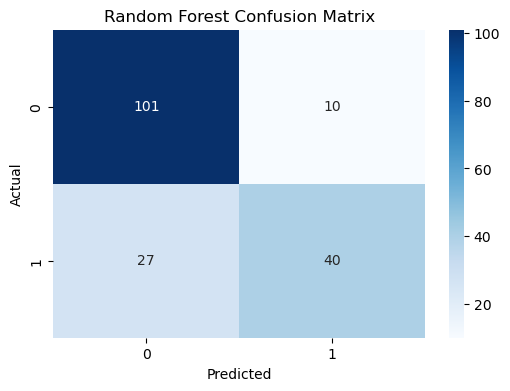

In [36]:
import seaborn as sns
# Ensure the title matches your actual variable (e.g., forest_cm)
plt.figure(figsize=(6, 4))
sns.heatmap(forest_cm, annot=True, fmt="d", cmap="Blues", cbar=True)
# Add labels and title
plt.title("Random Forest Confusion Matrix")  # Updated to match variable
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# The END